Dataset path: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/DS_IN/dataset_EURUSD_M5.csv
Первые строки датасета:
                 Time  Target1  Target2      M5_CCI  M5_CCI_lag1  M5_CCI_lag3  \
0 2018-01-02 05:20:00      2.0      2.0  133.718347    79.353766    18.279990   
1 2018-01-02 05:25:00      2.0      2.0  158.569834   133.718347    47.664342   
2 2018-01-02 05:30:00      2.0      2.0  133.239477   158.569834    79.353766   
3 2018-01-02 05:35:00      2.0      2.0  107.521368   133.239477   133.718347   
4 2018-01-02 05:40:00      2.0      2.0  106.852276   107.521368   158.569834   

      M5_RSI  M5_RSI_lag1  M5_RSI_lag3  M5_StochMain  ...  M5_Ret_4  M5_Ret_8  \
0  63.991378    60.012315    57.617696     91.194969  ...  0.000758  0.000849   
1  64.847513    63.991378    54.493966     96.348315  ...  0.000350  0.001033   
2  61.389418    64.847513    60.012315     92.287918  ...  0.000350  0.000808   
3  60.133640    61.389418    63.991378     87.468672  ...  0.000100  0.000766  

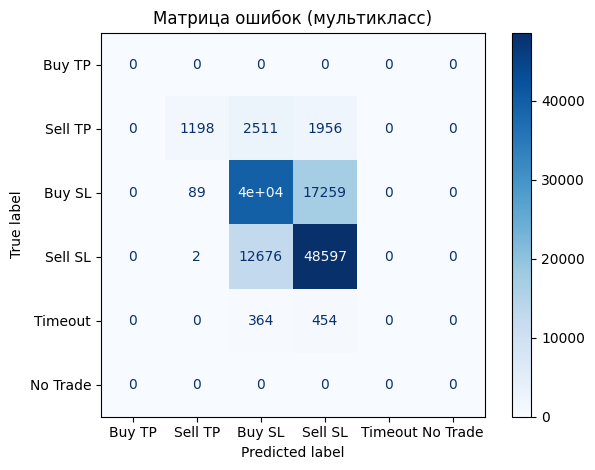

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/class_distribution_mcl.png


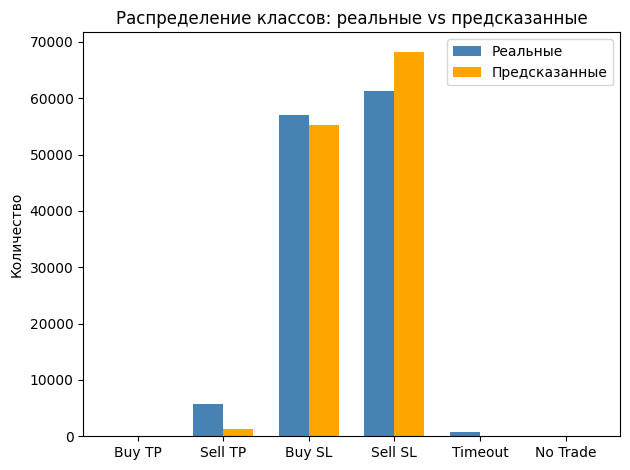

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/softmax_confidence_mcl.png


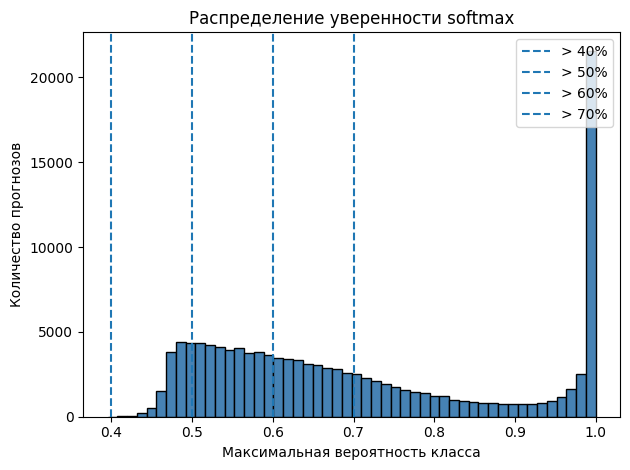

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/loss.png


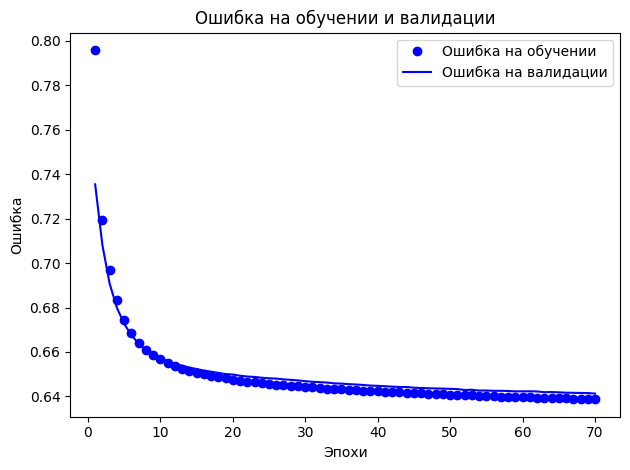

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/accuracy.png


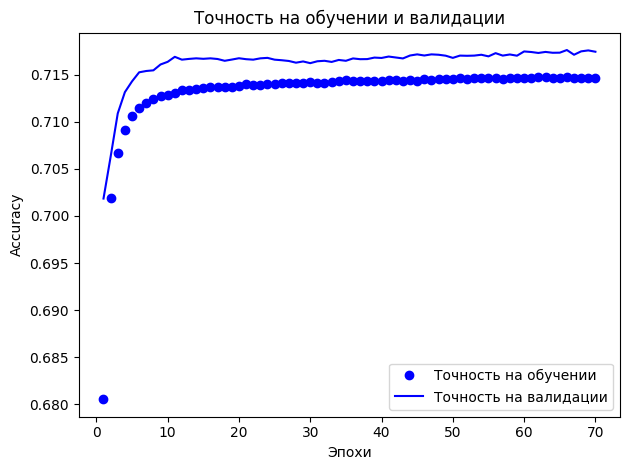

In [1]:
import main

history = main.main()
main.plot_training_history(history)

In [2]:
main.export_model(save_keras=True, save_ONNX=True, model_name="model")

INFO:tensorflow:Assets written to: exports/model_SavedModel/assets


2026-07-14 17:28:14,409 - WARNING - ***IMPORTANT*** Installed protobuf is not cpp accelerated. Conversion will be extremely slow. See https://github.com/onnx/tensorflow-onnx/issues/1557
2026-07-14 17:28:14,411 - WARNING - '--tag' not specified for saved_model. Using --tag serve
2026-07-14 17:28:15,271 - INFO - Signatures found in model: [serving_default].
2026-07-14 17:28:15,271 - WARNING - '--signature_def' not specified, using first signature: serving_default
2026-07-14 17:28:15,272 - INFO - Output names: ['dense_3']
2026-07-14 17:28:15.279210: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-07-14 17:28:15.279434: I tensorflow/core/grappler/clusters/single_machine.cc:358] Starting new session
2026-07-14 17:28:15.404183: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was

In [3]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession("exports/model.onnx")

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

x_sample = main.X_test[:10].astype(np.float32)

keras_pred = main.model.predict(x_sample, verbose=0)
onnx_pred = session.run([output_name], {input_name: x_sample})[0]

print(keras_pred.ravel())
print(onnx_pred.ravel())
print(np.max(np.abs(keras_pred - onnx_pred)))

[1.1798995e-06 1.7216692e-02 9.7196883e-01 1.0695134e-02 1.1814016e-04
 2.7707680e-11 5.1166471e-13 1.4674497e-01 3.7171376e-01 4.8053455e-01
 1.0067321e-03 1.3354348e-09 2.4016993e-09 6.6226035e-02 8.7480503e-01
 5.8644906e-02 3.2400416e-04 2.1049879e-10 6.8279720e-15 3.9797943e-02
 6.8829760e-02 8.9095974e-01 4.1251222e-04 3.8455786e-10 7.4324903e-06
 7.8934673e-03 9.8846173e-01 3.5595701e-03 7.7927238e-05 7.7833373e-12
 2.3262305e-14 5.4673355e-02 1.2922129e-01 8.1531966e-01 7.8562449e-04
 6.0723571e-10 9.4975052e-16 6.6800797e-03 2.2151489e-03 9.9109405e-01
 1.0800747e-05 4.7649756e-11 2.1647463e-06 2.6688520e-02 8.8059670e-01
 9.2633352e-02 7.9231737e-05 1.8029257e-11 7.0581907e-18 4.9374730e-04
 8.3493935e-05 9.9942124e-01 1.5470290e-06 8.6053846e-12 9.2043274e-06
 5.7345964e-03 9.9192822e-01 2.2707724e-03 5.7162662e-05 2.8676501e-12]
[1.17989953e-06 1.72166824e-02 9.71968830e-01 1.06951352e-02
 1.18140044e-04 2.77077319e-11 5.11663791e-13 1.46744967e-01
 3.71713728e-01 4.8053455

In [4]:
import numpy as np
from config import TASK
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix

# ------------------------------------------------------------
# Настройки классов
# ------------------------------------------------------------

CLASS_NAMES_6 = [
    "Buy TP",    # 0
    "Sell TP",   # 1
    "Buy SL",    # 2
    "Sell SL",   # 3
    "Timeout",   # 4
    "No Trade",  # 5
]

CLASS_NAMES_3 = [
    "Sell",
    "NoTrade",
    "Buy",
]

THRESHOLDS_SOFTMAX = [0.00, 0.33, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
THRESHOLDS_CLASSIFICATION = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.90]
THRESHOLDS_REGRESSION = [0.00, 0.10, 0.20, 0.30, 0.40, 0.50, 0.70, 0.90]


def print_distribution(title, values, class_names):
    print(title)
    for i, name in enumerate(class_names):
        print(f"  {i}: {name:<10} {np.sum(values == i):>8}")
    print()


def class_to_trade_signal_6(classes):
    """
    Торговая интерпретация 6 классов:
      0 Buy TP  -> Buy
      1 Sell TP -> Sell
      2 Buy SL  -> не входить
      3 Sell SL -> не входить
      4 Timeout -> не входить
      5 NoTrade -> не входить

    Возвращает:
      +1 Buy
      -1 Sell
       0 NoTrade
    """
    signals = np.zeros_like(classes, dtype="int32")
    signals[classes == 0] = 1
    signals[classes == 1] = -1
    return signals


def evaluate_6class_trading(y_true_class, y_pred_class, confidence, thresholds):
    """
    Строгая торговая оценка:
    - сделка открывается только если predicted class = Buy TP или Sell TP;
    - win только если predicted class точно совпал с true class;
    - любой другой true class для открытой сделки считается loss.
    """

    pred_signal = class_to_trade_signal_6(y_pred_class)

    print(f"{'Порог':>8} {'Сделок':>9} {'Coverage':>10} "
          f"{'Win':>9} {'Loss':>9} {'Buy':>9} {'Sell':>9} {'WinRate':>9}")
    print("-" * 86)

    for threshold in thresholds:
        trade_mask = (pred_signal != 0) & (confidence >= threshold)
        n = int(trade_mask.sum())

        if n == 0:
            continue

        pred_trades = y_pred_class[trade_mask]
        true_trades = y_true_class[trade_mask]

        wins = int(np.sum(pred_trades == true_trades))
        losses = n - wins

        buy_count = int(np.sum(pred_trades == 0))
        sell_count = int(np.sum(pred_trades == 1))

        coverage = n / len(y_true_class) * 100
        win_rate = wins / n * 100

        print(
            f"{threshold:>8.2f} {n:>9} {coverage:>9.1f}% "
            f"{wins:>9} {losses:>9} {buy_count:>9} {sell_count:>9} {win_rate:>8.1f}%"
        )

    print()


def print_6class_error_breakdown(y_true_class, y_pred_class):
    pred_signal = class_to_trade_signal_6(y_pred_class)
    trade_mask = pred_signal != 0

    if not trade_mask.any():
        print("Модель не дала ни одной торговой сделки.")
        print()
        return

    print("Разбор исходов по сделкам модели:")
    for i, name in enumerate(CLASS_NAMES_6):
        count = int(np.sum(y_true_class[trade_mask] == i))
        print(f"  true {i}: {name:<10} {count:>8}")

    print()


def regression_to_signals(pred, threshold):
    signals = np.zeros_like(pred, dtype="int32")
    signals[pred > threshold] = 1
    signals[pred < -threshold] = -1
    return signals


# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

raw_pred = main.model.predict(main.X_test, verbose=0)

print(f"TASK: {TASK}")
print(f"Форма raw prediction: {raw_pred.shape}")
print()


# ------------------------------------------------------------
# Multiclass
# ------------------------------------------------------------

if TASK == "multiclass":
    proba = raw_pred
    y_true = main.y_test.astype("int32").ravel()

    y_pred = np.argmax(proba, axis=1).astype("int32")
    confidence = proba.max(axis=1)

    num_classes = proba.shape[1]

    if num_classes == 6:
        class_names = CLASS_NAMES_6
        labels = list(range(6))

        print_distribution("Распределение реальных классов:", y_true, class_names)
        print_distribution("Распределение предсказанных классов:", y_pred, class_names)

        print("Balanced accuracy:")
        print(balanced_accuracy_score(y_true, y_pred))
        print()

        print("Classification report:")
        print(classification_report(
            y_true,
            y_pred,
            labels=labels,
            target_names=class_names,
            digits=4,
            zero_division=0,
        ))

        print("Confusion matrix:")
        print(confusion_matrix(y_true, y_pred, labels=labels))
        print()

        print("Первые 10 вероятностей:")
        print(np.round(proba[:10], 4))
        print("Первые 10 классов:")
        print(y_pred[:10])
        print("Первые 10 торговых сигналов (+1 Buy, -1 Sell, 0 NoTrade):")
        print(class_to_trade_signal_6(y_pred[:10]))
        print()

        print_6class_error_breakdown(y_true, y_pred)

        print("Торговая оценка: вход только при predicted Buy TP / Sell TP")
        evaluate_6class_trading(
            y_true_class=y_true,
            y_pred_class=y_pred,
            confidence=confidence,
            thresholds=THRESHOLDS_SOFTMAX,
        )

    elif num_classes == 3:
        class_names = CLASS_NAMES_3
        labels = list(range(3))

        print_distribution("Распределение реальных классов:", y_true, class_names)
        print_distribution("Распределение предсказанных классов:", y_pred, class_names)

        print("Balanced accuracy:")
        print(balanced_accuracy_score(y_true, y_pred))
        print()

        print("Classification report:")
        print(classification_report(
            y_true,
            y_pred,
            labels=labels,
            target_names=class_names,
            digits=4,
            zero_division=0,
        ))

        pred_signals = y_pred - 1
        true_signals = y_true - 1

        print("Первые 10 вероятностей [Sell, NoTrade, Buy]:")
        print(np.round(proba[:10], 4))
        print("Первые 10 торговых сигналов:")
        print(pred_signals[:10])
        print()

        print(f"{'Порог':>8} {'Сделок':>9} {'Coverage':>10} "
              f"{'Win':>9} {'Loss':>9} {'NoTrade FP':>11} {'WrongDir':>9} {'WinRate':>9}")
        print("-" * 96)

        for threshold in THRESHOLDS_SOFTMAX:
            trade_mask = (pred_signals != 0) & (confidence >= threshold)
            n = int(trade_mask.sum())

            if n == 0:
                continue

            pred_trades = pred_signals[trade_mask]
            true_for_trades = true_signals[trade_mask]

            wins = int(np.sum(pred_trades == true_for_trades))
            false_notrade = int(np.sum(true_for_trades == 0))
            wrong_direction = int(np.sum((true_for_trades != 0) & (pred_trades != true_for_trades)))
            losses = false_notrade + wrong_direction

            coverage = n / len(true_signals) * 100
            win_rate = wins / n * 100

            print(
                f"{threshold:>8.2f} {n:>9} {coverage:>9.1f}% "
                f"{wins:>9} {losses:>9} {false_notrade:>11} "
                f"{wrong_direction:>9} {win_rate:>8.1f}%"
            )

        print()

    else:
        raise ValueError(f"Неожиданное число softmax-классов: {num_classes}")


# ------------------------------------------------------------
# Binary classification
# ------------------------------------------------------------

elif TASK == "classification":
    proba_buy = raw_pred.ravel()
    y_raw = main.y_test.astype("float32").ravel()

    print("Binary classification режим.")
    print("Интерпретация: probability >= threshold -> Buy, иначе Sell.")
    print()

    print("Первые 10 вероятностей Buy:")
    print(np.round(proba_buy[:10], 4))
    print()

    print(f"{'Порог Buy':>10} {'Buy':>9} {'Sell':>9} {'Accuracy':>10}")
    print("-" * 44)

    for threshold in THRESHOLDS_CLASSIFICATION:
        pred = (proba_buy >= threshold).astype("int32")
        acc = np.mean(pred == y_raw) * 100

        print(
            f"{threshold:>10.2f} {np.sum(pred == 1):>9} {np.sum(pred == 0):>9} {acc:>9.1f}%"
        )

    print()


# ------------------------------------------------------------
# Regression
# ------------------------------------------------------------

elif TASK == "regression":
    pred = raw_pred.ravel()
    y_raw = main.y_test.astype("float32").ravel()

    y_signals = np.zeros_like(y_raw, dtype="int32")
    y_signals[y_raw > 0] = 1
    y_signals[y_raw < 0] = -1

    print("Regression prediction stats:")
    print(f"  min:    {pred.min():.6f}")
    print(f"  max:    {pred.max():.6f}")
    print(f"  mean:   {pred.mean():.6f}")
    print(f"  std:    {pred.std():.6f}")
    print(f"  median: {np.median(pred):.6f}")
    print()

    print(f"{'Порог |pred|':>14} {'Сделок':>9} {'Coverage':>10} "
          f"{'Win':>9} {'Loss':>9} {'WinRate':>9}")
    print("-" * 72)

    for threshold in THRESHOLDS_REGRESSION:
        pred_signals = regression_to_signals(pred, threshold)
        trade_mask = pred_signals != 0
        n = int(trade_mask.sum())

        if n == 0:
            continue

        wins = int(np.sum(pred_signals[trade_mask] == y_signals[trade_mask]))
        losses = n - wins
        coverage = n / len(y_signals) * 100
        win_rate = wins / n * 100

        print(
            f"{threshold:>14.2f} {n:>9} {coverage:>9.1f}% "
            f"{wins:>9} {losses:>9} {win_rate:>8.1f}%"
        )

    print()

else:
    raise ValueError(f"Неизвестный TASK: {TASK!r}")

TASK: multiclass
Форма raw prediction: (124761, 6)

Распределение реальных классов:
  0: Buy TP            0
  1: Sell TP        5665
  2: Buy SL        57003
  3: Sell SL       61275
  4: Timeout         818
  5: No Trade          0

Распределение предсказанных классов:
  0: Buy TP            0
  1: Sell TP        1289
  2: Buy SL        55206
  3: Sell SL       68266
  4: Timeout           0
  5: No Trade          0

Balanced accuracy:
0.4250589496469793

Classification report:
              precision    recall  f1-score   support

      Buy TP     0.0000    0.0000    0.0000         0
     Sell TP     0.9294    0.2115    0.3445      5665
      Buy SL     0.7183    0.6957    0.7068     57003
     Sell SL     0.7119    0.7931    0.7503     61275
     Timeout     0.0000    0.0000    0.0000       818
    No Trade     0.0000    0.0000    0.0000         0

    accuracy                         0.7170    124761
   macro avg     0.3933    0.2834    0.3003    124761
weighted avg     0.7200    